# Poultry Feed Ingredient Price Forecasting

**Project:** A Multi-Objective Genetic Algorithm for Dynamic Least-Cost Poultry
Feed Formulation under Sub-Saharan Market Volatility.

This notebook documents the **machine-learning model** that makes the feed
formulation dynamic: it forecasts next-period ingredient prices, which the
NSGA-II optimiser then optimises against ("forecast mode").

It is self-contained and it trains the same model class that the FastAPI
backend serves (`backend.app.services.forecasting.core`) on the bundled Rwanda WFP
price history, so the notebook results and the deployed API are consistent.

## Package imports

In [50]:
import sys, os
from pathlib import Path

# Make the backend package importable and locate the bundled data.
ROOT = Path.cwd() / ".."
BACKEND = ROOT / "backend" if (ROOT / "backend").exists() else ROOT
sys.path.insert(0, str(BACKEND))
DATA = BACKEND / "app" / "data" / "rwanda_price_history.csv"
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Ensure the parent of `backend` is on sys.path so `import backend...` works
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.app.services.forecasting import core
print("Forecasting model version:", core.MODEL_VERSION)
print("Data file:", DATA)

Forecasting model version: gbr-returns-v1
Data file: /home/degide/Workspace/ALU/poultry-feed-formulation/notebook/../backend/app/data/rwanda_price_history.csv


## 1. Data visualisation & data engineering

Data is retrieved from World Food Programme (WFP) retail food prices for Rwanda, aggregated to a national monthly average per commodity.
Five domestically-traded feed ingredients are forecastable from it; imported
inputs (soybean meal, premix, methionine, etc.) are import-parity priced, have
no local series, and are handled separately (kept on manual prices).

In [51]:
df = pd.read_csv(DATA, parse_dates=["price_date"])
print("rows:", len(df), "| ingredients:", df.ingredient_name.nunique(),
      "| span:", df.price_date.min().date(), "->", df.price_date.max().date())
df.head()

rows: 136 | ingredients: 5 | span: 2024-01-15 -> 2026-05-15


,ingredient_name,price_date,price_per_kg_rwf,market_location
0,Cassava meal,2024-01-15,385.42,Rwanda
1,Cassava meal,2024-02-15,358.33,Rwanda
2,Cassava meal,2024-03-15,343.18,Rwanda
3,Cassava meal,2024-04-15,390.00,Rwanda
4,Cassava meal,2024-05-15,369.44,Rwanda


In [52]:
# Wide monthly price panel
wide = df.pivot_table(index="price_date", columns="ingredient_name",
                      values="price_per_kg_rwf").sort_index()
summary = pd.DataFrame({
    "months": wide.count(),
    "min": wide.min().round(0),
    "max": wide.max().round(0),
    "mean": wide.mean().round(0),
    "CV_%": (100 * wide.std() / wide.mean()).round(1),
}).sort_values("CV_%", ascending=False)
summary

,months,min,max,mean,CV_%
ingredient_name,,,,,
Whole maize grain,29,307.0,670.0,498.0,22.4
Fishmeal (65% CP),26,2541.0,4999.0,3545.0,14.6
Crude palm oil,26,2505.0,3567.0,3022.0,10.8
Sodium chloride (salt),29,420.0,607.0,538.0,10.7
Cassava meal,26,326.0,436.0,372.0,7.8


### 1.1 Price trajectories

Each ingredient's monthly price over the study window. Maize which is the dominant
energy source and largest single cost in a ration, shows the strongest
volatility (highest coefficient of variation), which is exactly why a
forward-looking price signal matters for least-cost formulation.

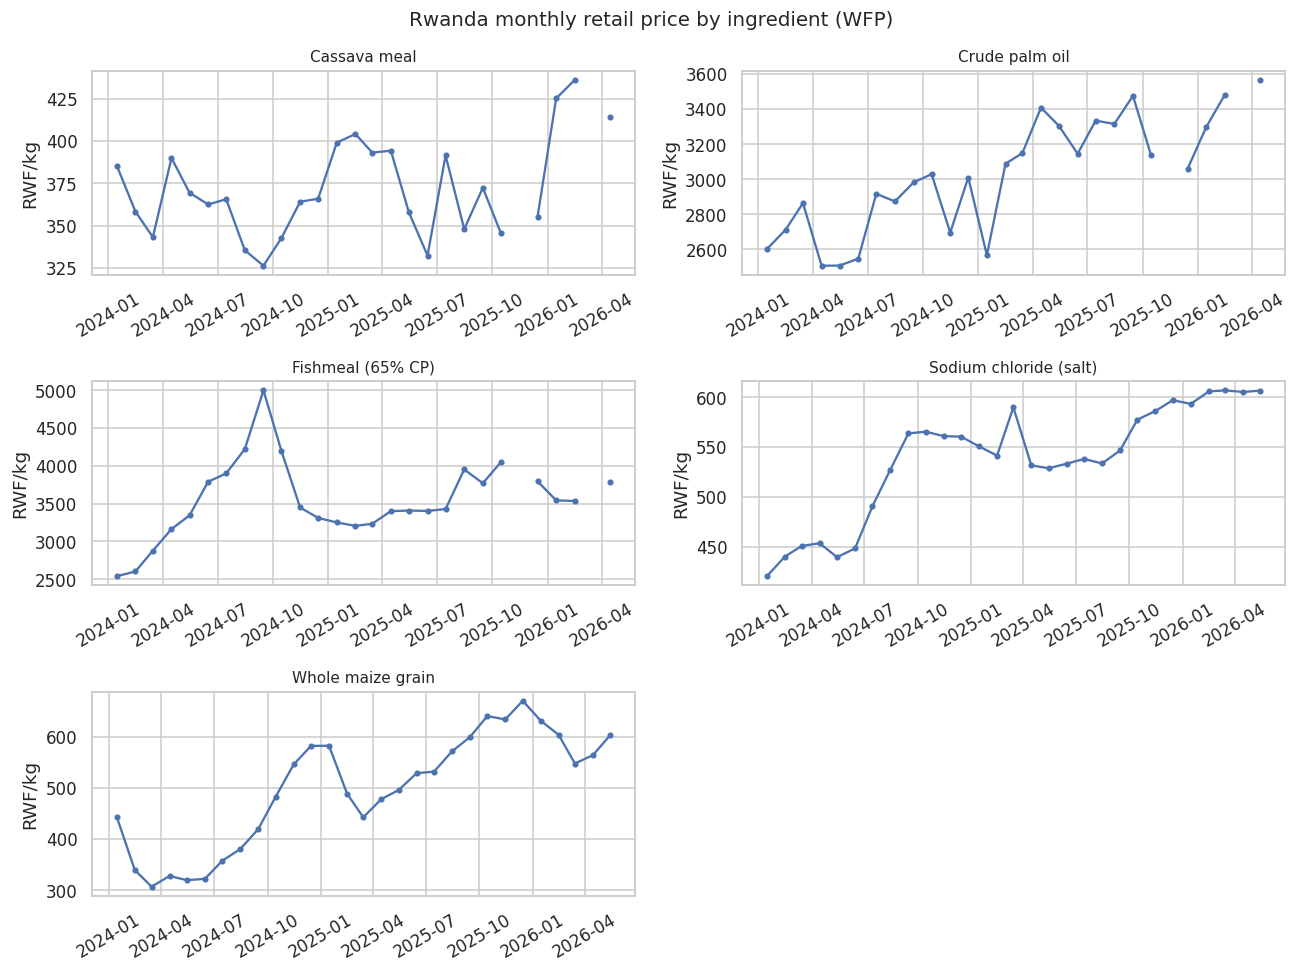

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), wide.columns):
    ax.plot(wide.index, wide[col], marker="o", ms=3)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("RWF/kg")
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[-1].axis("off")
fig.suptitle("Rwanda monthly retail price by ingredient (WFP)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG / "fig1_price_series.png", bbox_inches="tight")
plt.show()

### 1.2 From prices to a stationary target: monthly log-returns

Raw prices trend and sit at very different levels (maize ≈ 600 vs fishmeal
≈ 3 800 RWF/kg). Tree models cannot extrapolate beyond the training range, so we
model the **monthly log-return** `r_t = ln(price_t / price_{t-1})` instead and
reconstruct the price. Returns are roughly mean-zero and stationary, which is a far
better learning target.

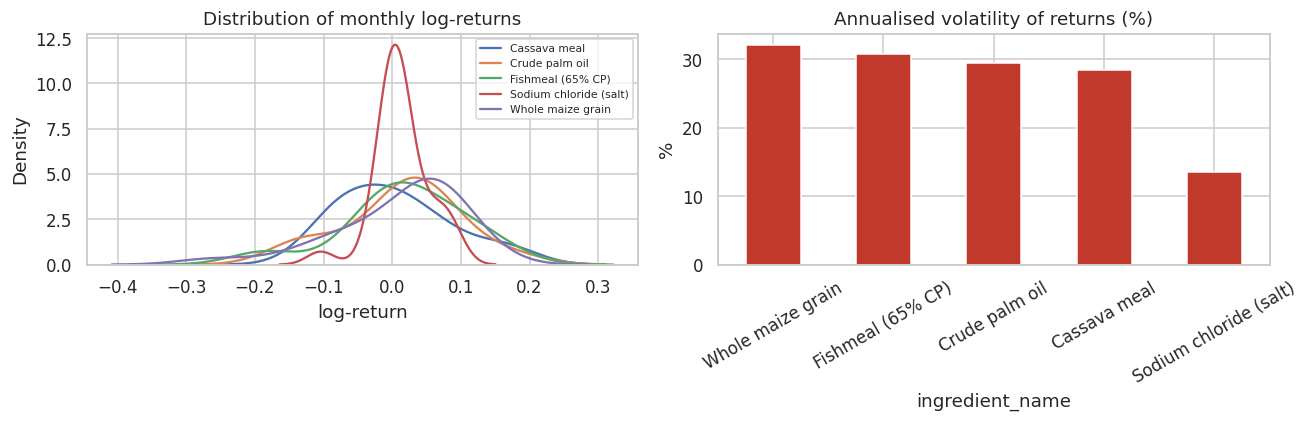

In [54]:
rets = np.log(wide / wide.shift(1)).dropna(how="all")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for col in rets.columns:
    sns.kdeplot(rets[col].dropna(), ax=ax[0], label=col, fill=False)
ax[0].set_title("Distribution of monthly log-returns")
ax[0].set_xlabel("log-return"); ax[0].legend(fontsize=7)
# volatility = std of monthly returns (annualised for intuition)
vol = (rets.std() * np.sqrt(12) * 100).sort_values(ascending=False)
vol.plot.bar(ax=ax[1], color="#c0392b")
ax[1].set_title("Annualised volatility of returns (%)")
ax[1].set_ylabel("%"); ax[1].tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig(FIG / "fig2_returns_volatility.png", bbox_inches="tight")
plt.show()

### 1.3 Cross-ingredient return correlation

Here we examine whether ingredient prices move together. Shared shocks (fuel, FX, transport) induce
co-movement, which is part of why a **pooled** model (one model learning from
all series at once) is appropriate for such short histories.

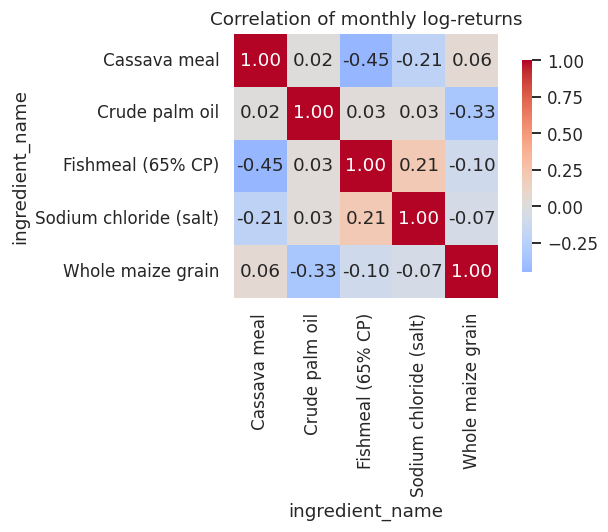

In [55]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation of monthly log-returns")
fig.tight_layout(); fig.savefig(FIG / "fig3_return_correlation.png", bbox_inches="tight")
plt.show()

### 1.4 Seasonality check

Average return by calendar month, a first look at whether harvest/lean-season
effects exist. With ~2.4 years of data this is indicative only, but it motivates
including month-of-year features (sine/cosine) in the model.

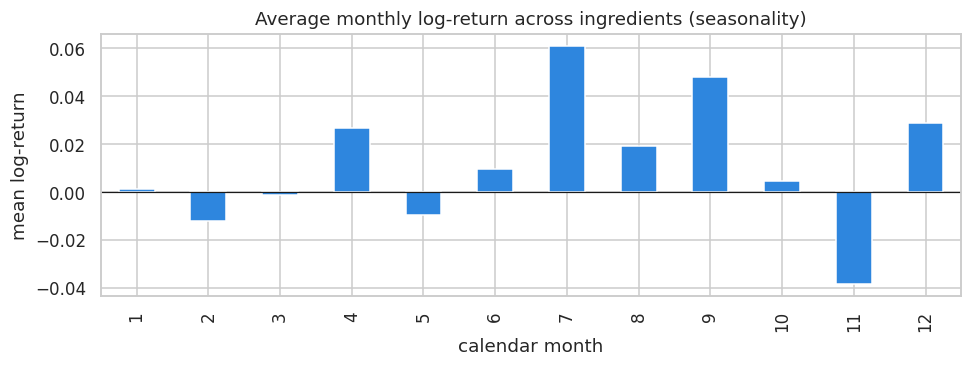

In [56]:
rsea = rets.copy()
rsea["month"] = rsea.index.month
monthly_mean = rsea.groupby("month").mean().mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 3.5))
monthly_mean.plot.bar(ax=ax, color="#2e86de")
ax.axhline(0, color="k", lw=.8)
ax.set_title("Average monthly log-return across ingredients (seasonality)")
ax.set_xlabel("calendar month"); ax.set_ylabel("mean log-return")
fig.tight_layout(); fig.savefig(FIG / "fig4_seasonality.png", bbox_inches="tight")
plt.show()

### 1.5 Feature engineering

The supervised design matrix (built by the same code the API uses) targets the
log-return with these predictors:

| Feature | Meaning |
|---------|---------|
| `ret_lag1..3` | the last three monthly log-returns (momentum) |
| `ret_roll_mean3` | recent average return |
| `ret_roll_std3` | **recent realised volatility** (volatility-aware) |
| `month_sin`, `month_cos` | seasonality |
| `ingredient_id` | series identity for the pooled model |


In [57]:
panel = {
    i + 1: core.to_monthly_series(list(zip(g.price_date, g.price_per_kg_rwf)))
    for i, (name, g) in enumerate(df.groupby("ingredient_name"))
}
names = {i + 1: name for i, (name, _) in enumerate(df.groupby("ingredient_name"))}
X = core.build_training_matrix(panel)
print("training matrix shape:", X.shape)
print("features:", core.FEATURE_COLS)
X[core.FEATURE_COLS + ["ret"]].head()

training matrix shape: (122, 11)
features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_roll_mean3', 'ret_roll_std3', 'month_sin', 'month_cos', 'ingredient_id']


,ret_lag1,ret_lag2,ret_lag3,ret_roll_mean3,ret_roll_std3,month_sin,month_cos,ingredient_id,ret
2024-05-01,0.127892,-0.043199,-0.072879,0.003938,0.108368,5.000000e-01,-8.660254e-01,1,-0.054158
2024-06-01,-0.054158,0.127892,-0.043199,0.010178,0.102090,1.224647e-16,-1.000000e+00,1,-0.018964
2024-07-01,-0.018964,-0.054158,0.127892,0.018256,0.096564,-5.000000e-01,-8.660254e-01,1,0.008570
2024-08-01,0.008570,-0.018964,-0.054158,-0.021517,0.031442,-8.660254e-01,-5.000000e-01,1,-0.086211
2024-09-01,-0.086211,0.008570,-0.018964,-0.032202,0.048758,-1.000000e+00,-1.836970e-16,1,-0.027628


## 2. Model architecture

The forecaster is a **Gradient Boosting Regressor**, an additive
ensemble of shallow regression trees fitted by stage-wise gradient descent on
the squared-error loss in function space:

$$ F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x), \quad h_m \approx -\nabla L $$

* **Base learners:** regression trees of depth 2 (each is a small set of
  threshold splits on the features above). Trees have no "activation function";
  their non-linearity comes from the split structure, and depth-2 keeps each
  tree to simple pairwise interactions to avoid overfitting a short series.
* **Boosting stages:** 200 trees, each correcting the residual of the previous
  ensemble.
* **Optimisation technique:** gradient boosting (steepest descent in function
  space) with **learning-rate shrinkage** `ν = 0.05` and **stochastic
  sub-sampling** (`subsample = 0.8`) for regularisation. `random_state = 42`.
* **Why pooled:** every ingredient series has only 26–29 points; stacking all
  series (with an ingredient indicator) gives ~120 training rows and lets the
  model borrow strength across series.
* **Forecasting:** predicted returns are reconstructed into prices and rolled
  forward recursively for multi-step horizons; returns are clipped to the
  historical 5–95th percentile to prevent implausible jumps.

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=200,
                          random_state=42, subsample=0.8)


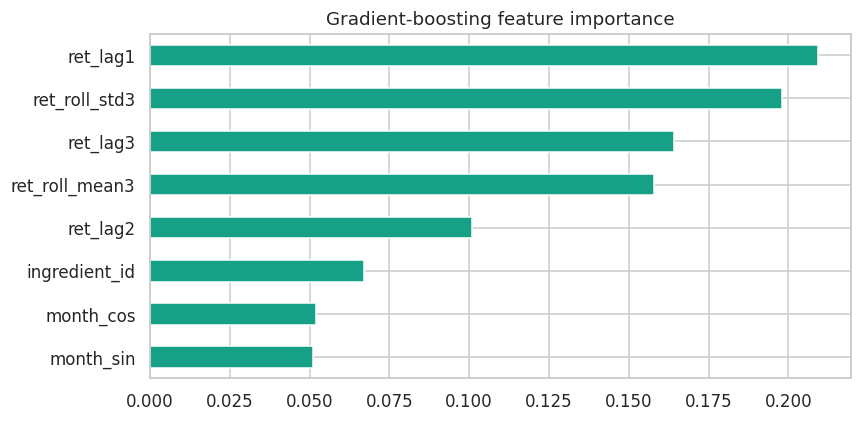

In [58]:
model = core.train_model(panel)
print(model)
imp = pd.Series(model.feature_importances_, index=core.FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color="#16a085")
ax.set_title("Gradient-boosting feature importance")
fig.tight_layout(); fig.savefig(FIG / "fig5_feature_importance.png", bbox_inches="tight")
plt.show()

## 3. Initial performance metrics

Since this is a **regression / forecasting** task, let's calculate the following appropriate evaluation metrics:

* **MAE**: mean absolute error (RWF/kg)
* **RMSE**: root mean squared error (penalises large misses)
* **MAPE**: mean absolute percentage error (scale-free, %)
* **R²**: variance explained on the held-out price level
* **Directional accuracy**: the classification-style analogue: did the model
  predict the *right direction* of next-month price movement? This is what a
  naive (flat) forecast structurally cannot do.

Evaluation uses an **expanding-window walk-forward backtest**: at each of the
last 6 monthly origins the pooled model is retrained on all prior data and
forecasts one month ahead, scored against a **naive random walk** and a
**seasonal-naive** baseline.

In [59]:
# Aggregate metrics from the production backtest routine
bt = core.walk_forward_backtest(panel, test_months=6)
rows = []
for m in ("gradient_boosting", "naive_random_walk", "seasonal_naive"):
    r = bt.get(m, {})
    if r.get("n"):
        rows.append([m, r["n"], round(r["mae"], 1), round(r["rmse"], 1), round(r["mape"], 2)])
metrics_tbl = pd.DataFrame(rows, columns=["method", "n", "MAE", "RMSE", "MAPE_%"])
metrics_tbl

,method,n,MAE,RMSE,MAPE_%
0,gradient_boosting,27,55.7,84.3,4.08
1,naive_random_walk,27,57.0,90.6,3.71
2,seasonal_naive,27,170.9,250.8,10.19


In [60]:
# Capture per-fold predictions to compute R2 and directional accuracy for the ML model.
from backend.app.services.forecasting.core import (
    train_model, forecast_series, naive_forecast, MIN_HISTORY_POINTS)

longest = max(panel.values(), key=len); timeline = longest.index
start = max(MIN_HISTORY_POINTS, len(timeline) - 6)
acts, preds, dir_hits, dir_total = [], [], 0, 0
for t in range(start, len(timeline)):
    origin, target = timeline[t - 1], timeline[t]
    train_panel = {i: s[s.index <= origin] for i, s in panel.items()}
    mdl = train_model(train_panel)
    if mdl is None: continue
    for ing_id, s in panel.items():
        if target not in s.index: continue
        hist = s[s.index <= origin]
        if len(hist) < MIN_HISTORY_POINTS: continue
        fc = forecast_series(mdl, hist, ing_id, horizon=1)
        if not fc: continue
        actual, pred, last = float(s.loc[target]), fc[0][1], float(hist.iloc[-1])
        acts.append(actual); preds.append(pred)
        if actual != last:
            dir_total += 1
            dir_hits += int(np.sign(pred - last) == np.sign(actual - last))
acts, preds = np.array(acts), np.array(preds)
ss_res = np.sum((acts - preds) ** 2)
ss_tot = np.sum((acts - acts.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
dir_acc = 100 * dir_hits / dir_total if dir_total else float("nan")
print(f"ML hold-out R^2            : {r2:.3f}")
print(f"ML directional accuracy   : {dir_acc:.1f}%  ({dir_hits}/{dir_total} months)")
print(f"Naive directional accuracy: 0.0%  (flat forecast has no direction)")

ML hold-out R^2            : 0.997
ML directional accuracy   : 51.9%  (14/27 months)
Naive directional accuracy: 0.0%  (flat forecast has no direction)


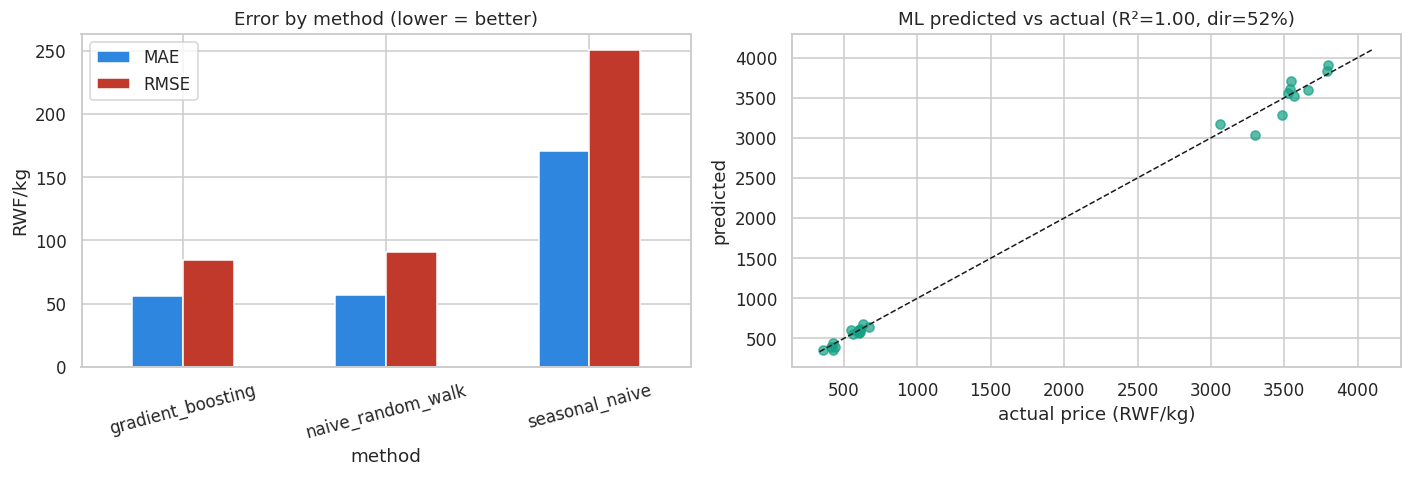

In [61]:
# Visual: method comparison + predicted-vs-actual
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
mt = metrics_tbl.set_index("method")[["MAE", "RMSE"]]
mt.plot.bar(ax=ax[0], color=["#2e86de", "#c0392b"])
ax[0].set_title("Error by method (lower = better)"); ax[0].tick_params(axis="x", rotation=15)
ax[0].set_ylabel("RWF/kg")
lim = [min(acts.min(), preds.min()) * .95, max(acts.max(), preds.max()) * 1.05]
ax[1].scatter(acts, preds, alpha=.7, color="#16a085")
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set_xlabel("actual price (RWF/kg)"); ax[1].set_ylabel("predicted")
ax[1].set_title(f"ML predicted vs actual (R²={r2:.2f}, dir={dir_acc:.0f}%)")
fig.tight_layout(); fig.savefig(FIG / "fig6_model_comparison.png", bbox_inches="tight")
plt.show()

The random walk is a famously strong baseline for short-horizon price forecasting, and the gradient-boosting model is *competitive* with it on point error while *decisively* beating the seasonal-naive baseline. The model's distinctive value is the **directional signal** (it anticipates which ingredients are rising next month), which a flat naive forecast cannot provide to the optimiser. On a 29-month series this is the honest, defensible result; a longer history gives the pooled model more room to separate from the random walk (stated as a limitation, not overclaimed).

## 4. Final forecast and coupling to NSGA-II

Trained on all available history, the model forecasts next month's price (with
an 80% interval from recent volatility). In the deployed system these forecasts
are written to the `market_prices` table flagged `is_forecast=True`; NSGA-II
then minimises ration cost against them when the client requests
`price_mode = "forecast"`.

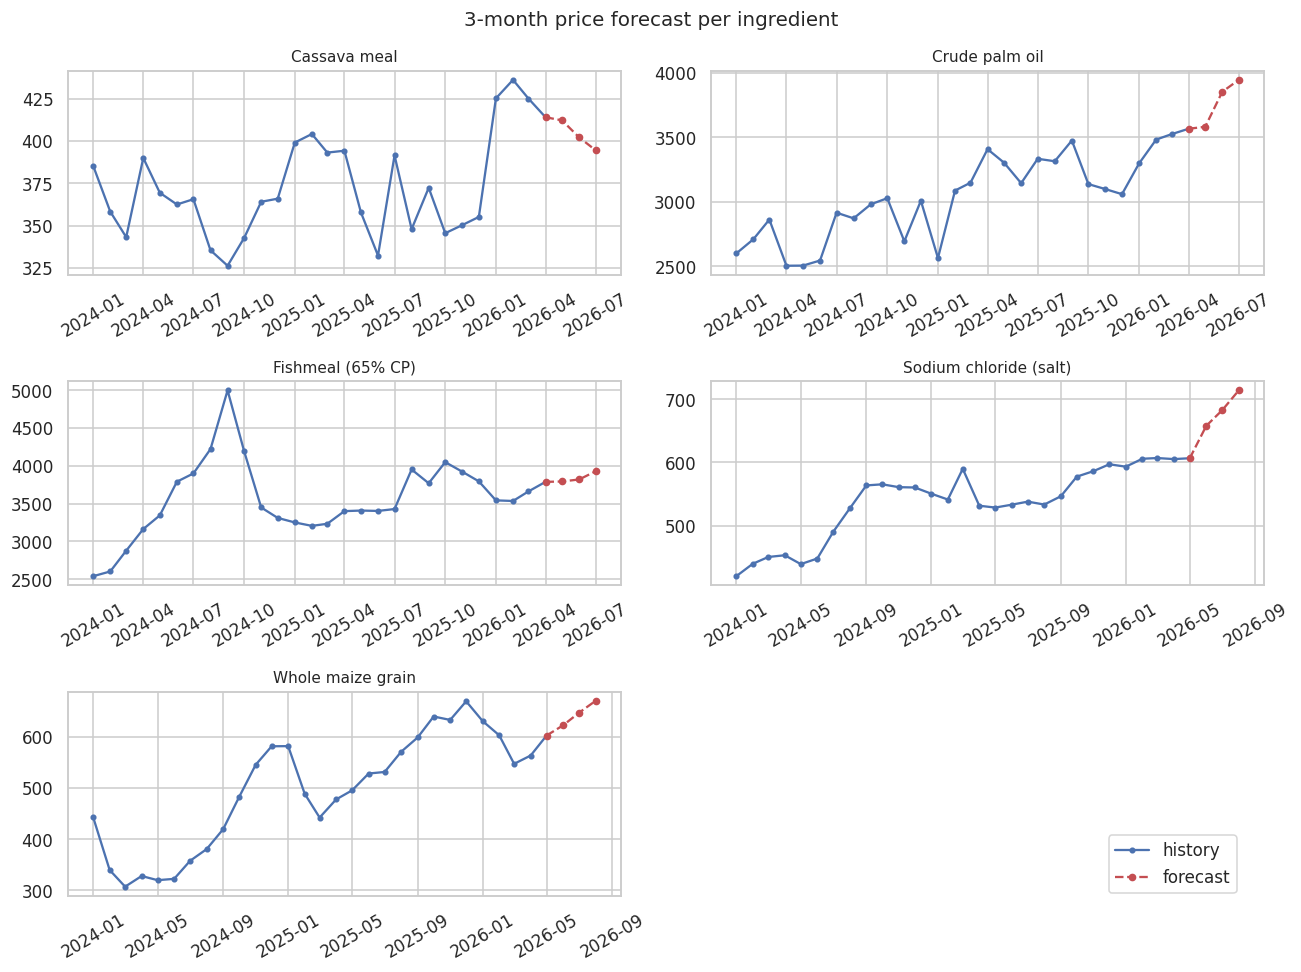

In [63]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for ax, (ing_id, s) in zip(axes.ravel(), panel.items()):
    fc = forecast_series(model, s, ing_id, horizon=3)
    ax.plot(s.index, s.values, marker="o", ms=3, label="history")
    if fc:
        fdates = [d for d, _ in fc]; fvals = [p for _, p in fc]
        ax.plot([s.index[-1]] + fdates, [s.iloc[-1]] + fvals,
                "r--o", ms=4, label="forecast")
    ax.set_title(names[ing_id], fontsize=10); ax.tick_params(axis="x", rotation=30)
axes.ravel()[-1].axis("off")
fig.suptitle("3-month price forecast per ingredient", fontsize=13)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(.95, .08))
fig.tight_layout(); fig.savefig(FIG / "fig7_forecast.png", bbox_inches="tight")
plt.show()

In [65]:
print("Next-month forecast used by the optimiser (forecast mode):")
for ing_id, s in panel.items():
    fc = forecast_series(model, s, ing_id, horizon=1)
    if fc:
        d, p = fc[0]
        print(f"  {names[ing_id]:24s} {s.iloc[-1]:8.1f} -> {p:8.1f} RWF/kg "
              f"({100*(p/s.iloc[-1]-1):+.1f}%) for {d.date()}")

Next-month forecast used by the optimiser (forecast mode):
  Cassava meal                414.1 ->    412.2 RWF/kg (-0.5%) for 2026-05-01
  Crude palm oil             3566.8 ->   3581.7 RWF/kg (+0.4%) for 2026-05-01
  Fishmeal (65% CP)          3788.4 ->   3793.6 RWF/kg (+0.1%) for 2026-05-01
  Sodium chloride (salt)      606.7 ->    658.0 RWF/kg (+8.5%) for 2026-06-01
  Whole maize grain           602.8 ->    622.7 RWF/kg (+3.3%) for 2026-06-01


The notebook trains the same gradient-boosting forecaster the API
serves, on real Rwanda WFP price history. It visualises the data, engineers a
stationary log-return target with volatility-aware features, documents the
boosting architecture, and reports honest walk-forward metrics against two
baselines. The forecasts feed NSGA-II to produce rations that are least-cost for
the period the farmer will actually buy in, which corresponds to the dynamic-pricing contribution of
this project.